# IVF Embryo Morphology Grading
This notebook demonstrates:
- Loading the trained **single-task quality** model (low/medium/high)
- Loading the trained **multi-task Gardner** model (Expansion/ICM/TE)
- Running inference on sample images
- Generating **confusion matrices** and **Grad-CAM** visualizations

**Project**: Deep Learning for Embryo Morphology Grading (IVF)


## 1) Environment & Project Setup

In [ ]:
import os
import sys
from pathlib import Path

# Ensure we run from the project root
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists() is False and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)


Project root: D:\Projects\ivf-embryo-grading


In [ ]:
import torch
import numpy as np

print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Python: 3.11.9
Torch: 2.10.0+cpu
Device: cpu


## 2) Load Project Paths (from `src/config.py`)

In [ ]:
from src import config

print("RAW_DATA_DIR:", config.RAW_DATA_DIR)
print("TRAIN_DIR:", config.TRAIN_DIR)
print("VAL_DIR:", config.VAL_DIR)
print("TEST_DIR:", config.TEST_DIR)
print("MODELS_DIR:", config.MODELS_DIR)
print("FIGURES_DIR:", config.FIGURES_DIR)


RAW_DATA_DIR: D:\Projects\ivf-embryo-grading\data\raw
TRAIN_DIR: D:\Projects\ivf-embryo-grading\data\processed\train
VAL_DIR: D:\Projects\ivf-embryo-grading\data\processed\val
TEST_DIR: D:\Projects\ivf-embryo-grading\data\processed\test
MODELS_DIR: D:\Projects\ivf-embryo-grading\src\models
FIGURES_DIR: D:\Projects\ivf-embryo-grading\reports\figures


## 3) Inspect Annotations (Train/Test)

In [ ]:
import pandas as pd
from src.utils.annotation_utils import load_annotations, add_quality_label

df_train = load_annotations("train")
df_test = load_annotations("test")

df_train_q = add_quality_label(df_train)
df_test_q = add_quality_label(df_test)

display(df_train_q.head(5))
print("Train size (quality):", len(df_train_q))
print(df_train_q["quality"].value_counts())

print("\nTest size (quality):", len(df_test_q))
print(df_test_q["quality"].value_counts())


,image,expansion,icm,te,quality
0,0175_05.png,3,1,1,high
1,420_02.png,3,0,0,low
2,680_01.png,2,0,0,low
3,340_03.png,3,0,1,low
4,571_02.png,0,3,3,low


Train size (quality): 2044
quality
low       1891
high        89
medium      64
Name: count, dtype: int64

Test size (quality): 300
quality
low       243
medium     37
high       20
Name: count, dtype: int64


## 4) Helper: Pick a Sample Image from the Test Set

Sample image: D:\Projects\ivf-embryo-grading\data\processed\test\high\0116_03.png


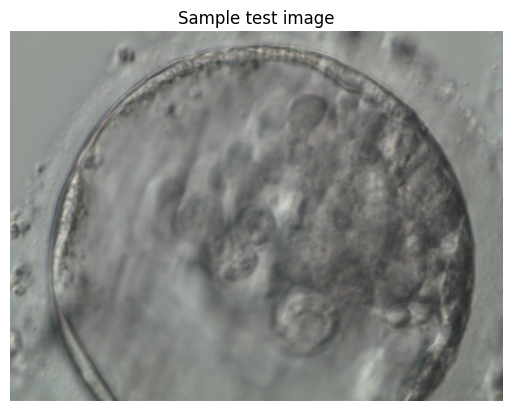

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

def pick_any_test_image() -> Path:
    root = Path(config.TEST_DIR)
    candidates = sorted(root.rglob("*.png")) + sorted(root.rglob("*.jpg")) + sorted(root.rglob("*.jpeg"))
    if not candidates:
        raise FileNotFoundError(f"No images found under: {root}")
    return candidates[0]

sample_img_path = pick_any_test_image()
print("Sample image:", sample_img_path)

img = Image.open(sample_img_path).convert("RGB")
plt.figure()
plt.imshow(img)
plt.axis("off")
plt.title("Sample test image")
plt.show()


## 5) Single-Task Model: Quality Prediction (low/medium/high)

In [ ]:
import torch.nn.functional as F
from src.models.cnn_model import create_model

single_ckpt = Path(config.MODELS_DIR) / "best_efficientnet_b0.pth"
assert single_ckpt.exists(), f"Missing checkpoint: {single_ckpt}"
print("Single-task checkpoint:", single_ckpt)

single_model = create_model(model_name="efficientnet_b0", num_classes=3)

state = torch.load(single_ckpt, map_location=DEVICE)
if isinstance(state, dict) and "model_state_dict" in state:
    single_model.load_state_dict(state["model_state_dict"])
else:
    single_model.load_state_dict(state)

single_model.to(DEVICE).eval()

QUALITY_CLASSES = ["low", "medium", "high"]

Single-task checkpoint: D:\Projects\ivf-embryo-grading\src\models\best_efficientnet_b0.pth


In [ ]:
import torchvision.transforms as T

single_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict_quality(img_path: Path):
    img = Image.open(img_path).convert("RGB")
    x = single_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = single_model(x)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()
        pred = int(np.argmax(probs))
    return QUALITY_CLASSES[pred], probs

pred_label, probs = predict_quality(sample_img_path)
print("Predicted quality:", pred_label)
print("Probabilities:", {c: float(p) for c, p in zip(QUALITY_CLASSES, probs)})


Predicted quality: low
Probabilities: {'low': 0.9459668397903442, 'medium': 0.01929471641778946, 'high': 0.034738458693027496}


### 5.1 Single-Task Grad-CAM

Grad-CAM saved to: D:\Projects\ivf-embryo-grading\reports\figures\gradcam_efficientnet_b0.png


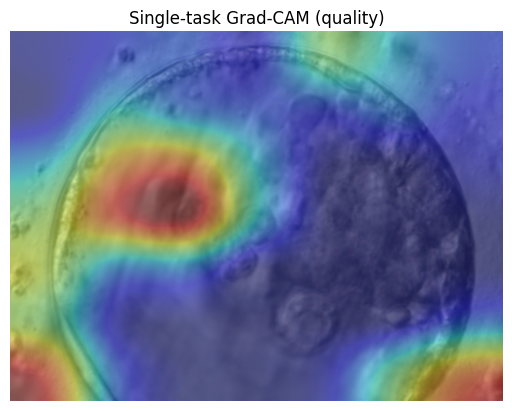

In [ ]:
from src.utils.grad_cam import generate_gradcam_for_image

out_path = generate_gradcam_for_image(str(sample_img_path), model_name="efficientnet_b0")
print("Grad-CAM saved to:", out_path)

cam_img = Image.open(out_path).convert("RGB")
plt.figure()
plt.imshow(cam_img)
plt.axis("off")
plt.title("Single-task Grad-CAM (quality)")
plt.show()


## 6) Multi-Task Model: Gardner Scores (Expansion/ICM/TE)

In [ ]:
from src.models.multitask_model import MultiTaskEmbryoNet

multi_ckpt = Path(config.MODELS_DIR) / "best_multitask_efficientnet_b0.pth"
assert multi_ckpt.exists(), f"Missing checkpoint: {multi_ckpt}"
print("Multi-task checkpoint:", multi_ckpt)

multi_model = MultiTaskEmbryoNet(
    num_expansion_classes=5,
    num_icm_classes=4,
    num_te_classes=4,
    pretrained=False,
)
mstate = torch.load(multi_ckpt, map_location=DEVICE)
if isinstance(mstate, dict) and "model_state_dict" in mstate:
    multi_model.load_state_dict(mstate["model_state_dict"])
else:
    multi_model.load_state_dict(mstate)
multi_model.to(DEVICE).eval()


Multi-task checkpoint: D:\Projects\ivf-embryo-grading\src\models\best_multitask_efficientnet_b0.pth


MultiTaskEmbryoNet(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              

In [ ]:
multi_tf = single_tf  # same preprocessing

def _unpack_multitask_outputs(outputs):
    # Supports either tuple/list or dict outputs
    if isinstance(outputs, dict):
        return outputs["expansion"], outputs["icm"], outputs["te"]
    if isinstance(outputs, (tuple, list)) and len(outputs) == 3:
        return outputs[0], outputs[1], outputs[2]
    raise TypeError(f"Unexpected multi-task output type: {type(outputs)}")

def predict_gardner(img_path: Path):
    img = Image.open(img_path).convert("RGB")
    x = multi_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = multi_model(x)
        exp_logits, icm_logits, te_logits = _unpack_multitask_outputs(out)

        exp_p = F.softmax(exp_logits, dim=1)[0].cpu().numpy()
        icm_p = F.softmax(icm_logits, dim=1)[0].cpu().numpy()
        te_p  = F.softmax(te_logits, dim=1)[0].cpu().numpy()

        exp_pred = int(np.argmax(exp_p))
        icm_pred = int(np.argmax(icm_p))
        te_pred  = int(np.argmax(te_p))

    return (exp_pred, icm_pred, te_pred), (exp_p, icm_p, te_p)

(exp_pred, icm_pred, te_pred), (exp_p, icm_p, te_p) = predict_gardner(sample_img_path)
print("Predicted Expansion:", exp_pred, "Probs:", exp_p)
print("Predicted ICM:", icm_pred, "Probs:", icm_p)
print("Predicted TE:", te_pred, "Probs:", te_p)


Predicted Expansion: 4 Probs: [0.22308378 0.14773771 0.10965398 0.20314388 0.31638065]
Predicted ICM: 3 Probs: [0.21627857 0.2333815  0.24645251 0.30388737]
Predicted TE: 2 Probs: [0.10438867 0.20631607 0.47323376 0.21606147]


### 6.1 Multi-Task Confusion Matrices

In [ ]:
import subprocess
from pathlib import Path

PROJECT_ROOT = (Path.cwd() / "..").resolve()
PY = str((PROJECT_ROOT / ".venv" / "Scripts" / "python.exe").resolve())

cmd = [PY, "-m", "src.utils.multitask_eval"]
print("Running:", " ".join(cmd))
print("CWD:", PROJECT_ROOT)

subprocess.check_call(cmd, cwd=str(PROJECT_ROOT))

Running: D:\Projects\ivf-embryo-grading\.venv\Scripts\python.exe -m src.utils.multitask_eval
CWD: D:\Projects\ivf-embryo-grading


0

D:\Projects\ivf-embryo-grading\reports\figures\confusion_multitask_expansion.png exists: True


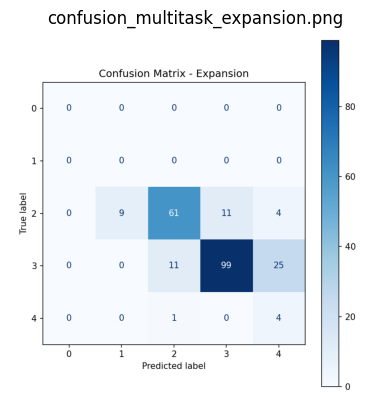

D:\Projects\ivf-embryo-grading\reports\figures\confusion_multitask_icm.png exists: True


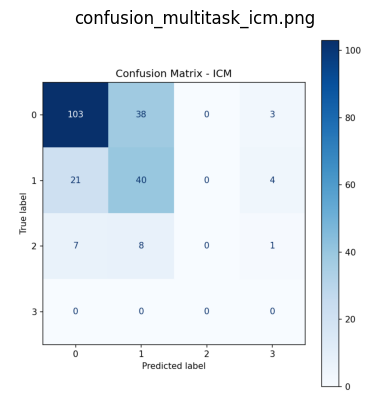

D:\Projects\ivf-embryo-grading\reports\figures\confusion_multitask_te.png exists: True


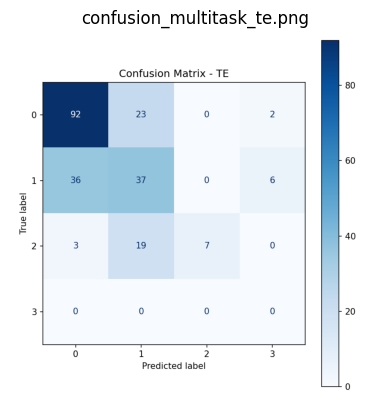

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from src import config

FIG_DIR = Path(config.FIGURES_DIR)

figs = [
    FIG_DIR / "confusion_multitask_expansion.png",
    FIG_DIR / "confusion_multitask_icm.png",
    FIG_DIR / "confusion_multitask_te.png",
]

for f in figs:
    print(f, "exists:", f.exists())
    if f.exists():
        plt.figure()
        plt.imshow(Image.open(f).convert("RGB"))
        plt.axis("off")
        plt.title(f.name)
        plt.show()

### 6.2 Multi-Task Grad-CAM (per head)

In [ ]:
import subprocess
from pathlib import Path

PROJECT_ROOT = (Path.cwd() / "..").resolve()
PY = str((PROJECT_ROOT / ".venv" / "Scripts" / "python.exe").resolve())

cmd = [PY, "-m", "src.utils.gradcam_multitask_demo"]
print("Running:", " ".join(cmd))
print("CWD:", PROJECT_ROOT)

subprocess.check_call(cmd, cwd=str(PROJECT_ROOT))

Running: D:\Projects\ivf-embryo-grading\.venv\Scripts\python.exe -m src.utils.gradcam_multitask_demo
CWD: D:\Projects\ivf-embryo-grading


0

D:\Projects\ivf-embryo-grading\reports\figures\gradcam_multitask_expansion.png exists: True


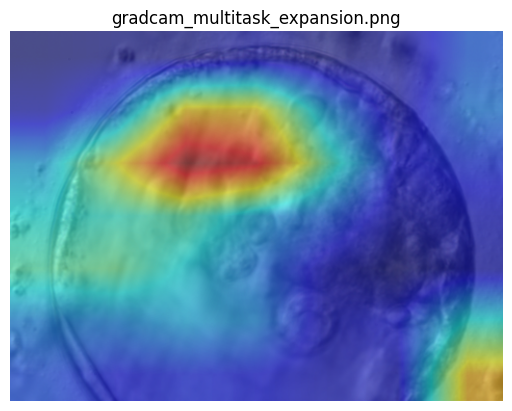

D:\Projects\ivf-embryo-grading\reports\figures\gradcam_multitask_icm.png exists: True


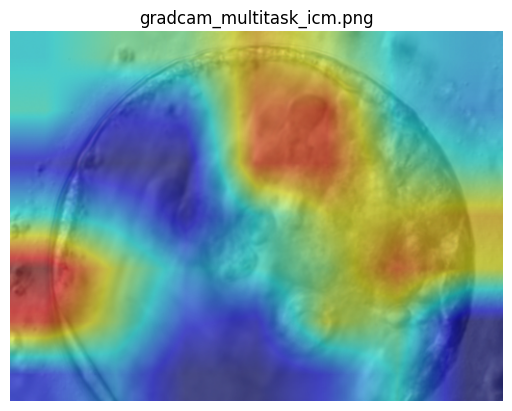

D:\Projects\ivf-embryo-grading\reports\figures\gradcam_multitask_te.png exists: True


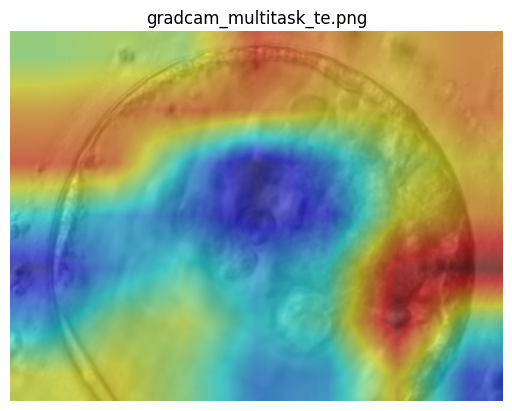

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from src import config

FIG_DIR = Path(config.FIGURES_DIR)
cam_figs = [
    FIG_DIR / "gradcam_multitask_expansion.png",
    FIG_DIR / "gradcam_multitask_icm.png",
    FIG_DIR / "gradcam_multitask_te.png",
]

for f in cam_figs:
    print(f, "exists:", f.exists())
    if f.exists():
        plt.figure()
        plt.imshow(Image.open(f).convert("RGB"))
        plt.axis("off")
        plt.title(f.name)
        plt.show()

## 7) Quality Model Curves (Accuracy/Loss)

In [ ]:
import subprocess
from pathlib import Path

PROJECT_ROOT = (Path.cwd() / "..").resolve()
PY = str((PROJECT_ROOT / ".venv" / "Scripts" / "python.exe").resolve())

cmd = [PY, "-m", "src.utils.plot_history"]
print("Running:", " ".join(cmd))
print("CWD:", PROJECT_ROOT)

subprocess.check_call(cmd, cwd=str(PROJECT_ROOT))

Running: D:\Projects\ivf-embryo-grading\.venv\Scripts\python.exe -m src.utils.plot_history
CWD: D:\Projects\ivf-embryo-grading


0

D:\Projects\ivf-embryo-grading\reports\figures\accuracy_efficientnet_b0.png exists: True


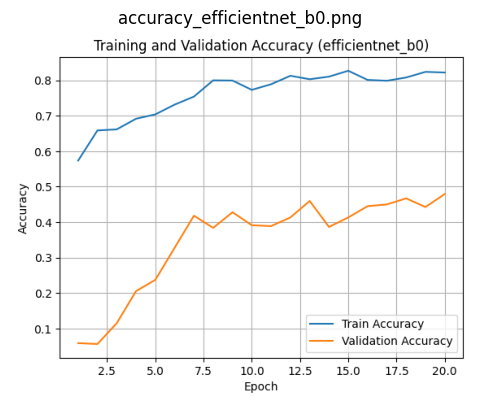

D:\Projects\ivf-embryo-grading\reports\figures\loss_efficientnet_b0.png exists: True


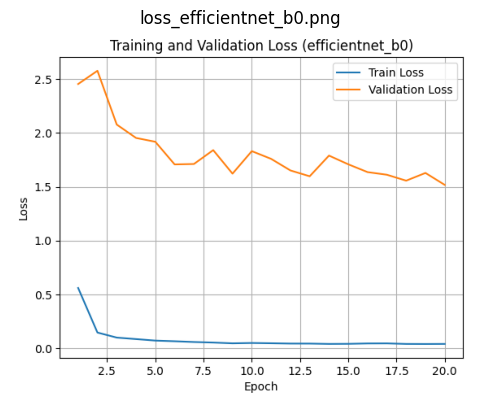

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from src import config

acc_fig = Path(config.FIGURES_DIR) / "accuracy_efficientnet_b0.png"
loss_fig = Path(config.FIGURES_DIR) / "loss_efficientnet_b0.png"

for f in [acc_fig, loss_fig]:
    print(f, "exists:", f.exists())
    if f.exists():
        plt.figure()
        plt.imshow(Image.open(f).convert("RGB"))
        plt.axis("off")
        plt.title(f.name)
        plt.show()

## 8) Notes
- If you move the repository, update paths in `src/config.py`.
- Dataset folders are typically excluded from Git history via `.gitignore`.
- Metrics can vary with dataset split, class imbalance, and hyperparameters.


# Final Analysis and Discussion

## Model Performance

In this project, a deep learning pipeline was developed for automatic embryo morphology grading from microscopic images. Two modeling strategies were explored:

- **Single-task classification** for predicting overall embryo quality *(low, medium, high)*.
- **Multi-task learning** for predicting individual Gardner grading components:
  - **Expansion stage**
  - **Inner Cell Mass (ICM)**
  - **Trophectoderm (TE)**

The **EfficientNet-B0** architecture was used as the backbone CNN due to its strong performance-to-complexity tradeoff for medical imaging tasks.

Training results show that the **training accuracy reached approximately 82%**, while **validation accuracy stabilized around 45–50%**.  
The gap between training and validation performance indicates the presence of **moderate overfitting**, which is expected given the limited dataset size.

---

## Error Analysis

The confusion matrices reveal several important patterns:

- The **low-quality class dominates the dataset**, which biases the model toward predicting this class more frequently.
- **Medium and high quality embryos are occasionally confused**, indicating that the morphological differences between these classes are subtle and difficult to learn from limited data.

In the **multi-task setting**:

- **Expansion prediction performs relatively well**, particularly for stages 2–3.
- **ICM and TE predictions are more challenging**, likely due to the fine structural differences in these regions.

These results are consistent with clinical observations where **ICM and TE grading require careful visual inspection even for experienced embryologists**.

---

## Model Interpretability (Grad-CAM)

Grad-CAM visualizations were used to investigate where the model focuses when making predictions.

The attention maps show that the model tends to highlight biologically meaningful regions:

- The **blastocoel cavity** for expansion prediction
- The **inner cell cluster** for ICM prediction
- The **outer cellular layer** for TE prediction

This behavior suggests that the model is learning **relevant morphological structures**, increasing confidence in the interpretability of the predictions.

---

## Limitations

Several limitations affect the performance of the current system:

- Limited dataset size
- Class imbalance, especially for rare grades
- Subtle morphological differences between classes
- Potential variability in imaging conditions

These factors contribute to the **generalization gap between training and validation performance**.

---

## Future Work

Several improvements could further enhance the system:

- Larger and more balanced embryo datasets
- Stronger **data augmentation strategies**
- **Class-balanced loss functions**
- Integration of **clinical metadata**
- Evaluation on **external IVF datasets**

Additionally, exploring more recent architectures *(e.g., Vision Transformers or hybrid CNN-Transformer models)* could further improve feature representation.

---

## Conclusion

This project demonstrates that deep learning models can learn meaningful morphological representations for embryo grading from microscopic images. While the current results highlight the challenges of limited medical datasets, the use of **multi-task learning and interpretability techniques** provides a promising direction toward **AI-assisted embryo evaluation in IVF workflows**.